# Create Correlation Plots Showing the Relationship Between Variables During Heat Waves and Cold Snaps


In [1]:
# Start by importing the packages we need:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Suppress Warnings


In [2]:
# Suppress future warnings:
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None


## Set the Directory Structure

In [3]:
# Set the data input and output directories:
metadata_input_dir =  '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/data/'
events_data_input_dir =  '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/data/thermal_events_data/'
image_output_dir =  '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/figures/regional_results/'


## Plot the Correlation Between Variables


In [45]:
def plot_hw_cs_correlations(region: int, hw_cs: str, events_data_input_dir: str, metadata_input_dir: str, image_output_dir: str, image_resolution: int, save_images=False):

    # Read in NERC region name file and extract the TPL-08 region name:
    nerc = pd.read_csv((metadata_input_dir + 'nerc_tpl08_region_names.csv'))
    nerc_name = nerc.loc[nerc['short_name'] == region, 'long_name'].item()
    
    # Extract the heat wave or cold snap library data for a given NERC region:
    if hw_cs == 'HW':
       hw_cs_df = pd.read_csv((events_data_input_dir + 'hw_library_expanded.csv'))
    elif hw_cs == 'CS':
       hw_cs_df = pd.read_csv((events_data_input_dir + 'cs_library_expanded.csv'))

    # Subset to just the data for region you want to use:
    subset_df = hw_cs_df[(hw_cs_df['Region'] == region)].copy()
    
    # For cold snaps, shift the centroid date to plot whole winter seasons together:
    if hw_cs == 'CS':
       subset_df.loc[(subset_df['Center_DOY'] > 182), 'Center_DOY'] = subset_df['Center_DOY']-365

    # Drop rows containing NaN import values (i.e., no GridView results):
    subset_df.dropna(subset=['Import_at_Peak'], inplace=True)

    # Simplify the column names:
    subset_df.rename(columns={'Center_DOY': 'Day of Year',
                              'T_Max_Min': 'Temperature',
                              'Regions_Impacted': 'Spatial Extent',
                              'Region_Load_Peak': 'Regional Peak Demand',
                              'WECC_Load_Peak': 'Interconnection Peak Demand',
                              'Coal_at_Peak': 'Coal at Peak Demand',
                              'Gas_at_Peak': 'Gas at Peak Demand',
                              'Hydro_at_Peak': 'Hydro at Peak Demand',
                              'Other_at_Peak': 'Other at Peak Demand',
                              'Solar_at_Peak': 'Solar at Peak Demand',
                              'Wind_at_Peak': 'Wind at Peak Demand',
                              'Import_at_Peak': 'Imports at Peak Demand',
                              'Max_LMP': 'Maximum LMP',
                              'LMP_at_Peak': 'LMP at Peak Demand',
                              'Load_Shed_at_Peak': 'Load Shed at Peak Demand',
                              'Max_Imports': 'Maximum Imports',
                              'Max_Load_Shed': 'Maximum Load Shed'}, inplace=True)

    # Only keep the columns we need and reset the index:
    subset_df = subset_df[['Regional Peak Demand','Interconnection Peak Demand','Maximum LMP','LMP at Peak Demand','Maximum Load Shed','Load Shed at Peak Demand','Maximum Imports','Imports at Peak Demand',
                           'Day of Year','Temperature','Spatial Extent',
                           'Coal at Peak Demand','Gas at Peak Demand','Hydro at Peak Demand','Other at Peak Demand','Solar at Peak Demand','Wind at Peak Demand']].copy()
    subset_df = subset_df.reset_index(drop=True)

    # Calculate the correlation matrix:
    corr = subset_df.corr(method='pearson',numeric_only=True)
    
    # Fill diagonal and upper half with NaNs
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    corr[mask] = np.nan

    # Create the colormap:
    cmap = plt.get_cmap('RdBu_r', 24)
    
    # Make the scatter plot:
    f = plt.figure(figsize=(20, 20))
    plt.rcParams['font.size'] = 18
    plt.rcParams['axes.axisbelow'] = True

    sns.heatmap(corr, cmap=cmap, vmin=-1, vmax=1, annot=True, fmt=".2f", linewidth=.5, linecolor='k', clip_on=False)

    if hw_cs == 'HW':
       plt.title(('Variable Correlations During Heat Waves in the ' + nerc_name + ' Region (N=' + str(subset_df.shape[0]) + ')'))
    else:
       plt.title(('Variable Correlations During Cold Snaps in the ' + nerc_name + ' Region (N=' + str(subset_df.shape[0]) + ')'))

    # If the "save_images" flag is set to true then save the plot to a .png file:
    if save_images == True:
       plt.savefig(os.path.join(image_output_dir + str(region) + '_' + hw_cs + '_Correlations.png'), dpi=image_resolution, bbox_inches='tight')
       plt.close()
    

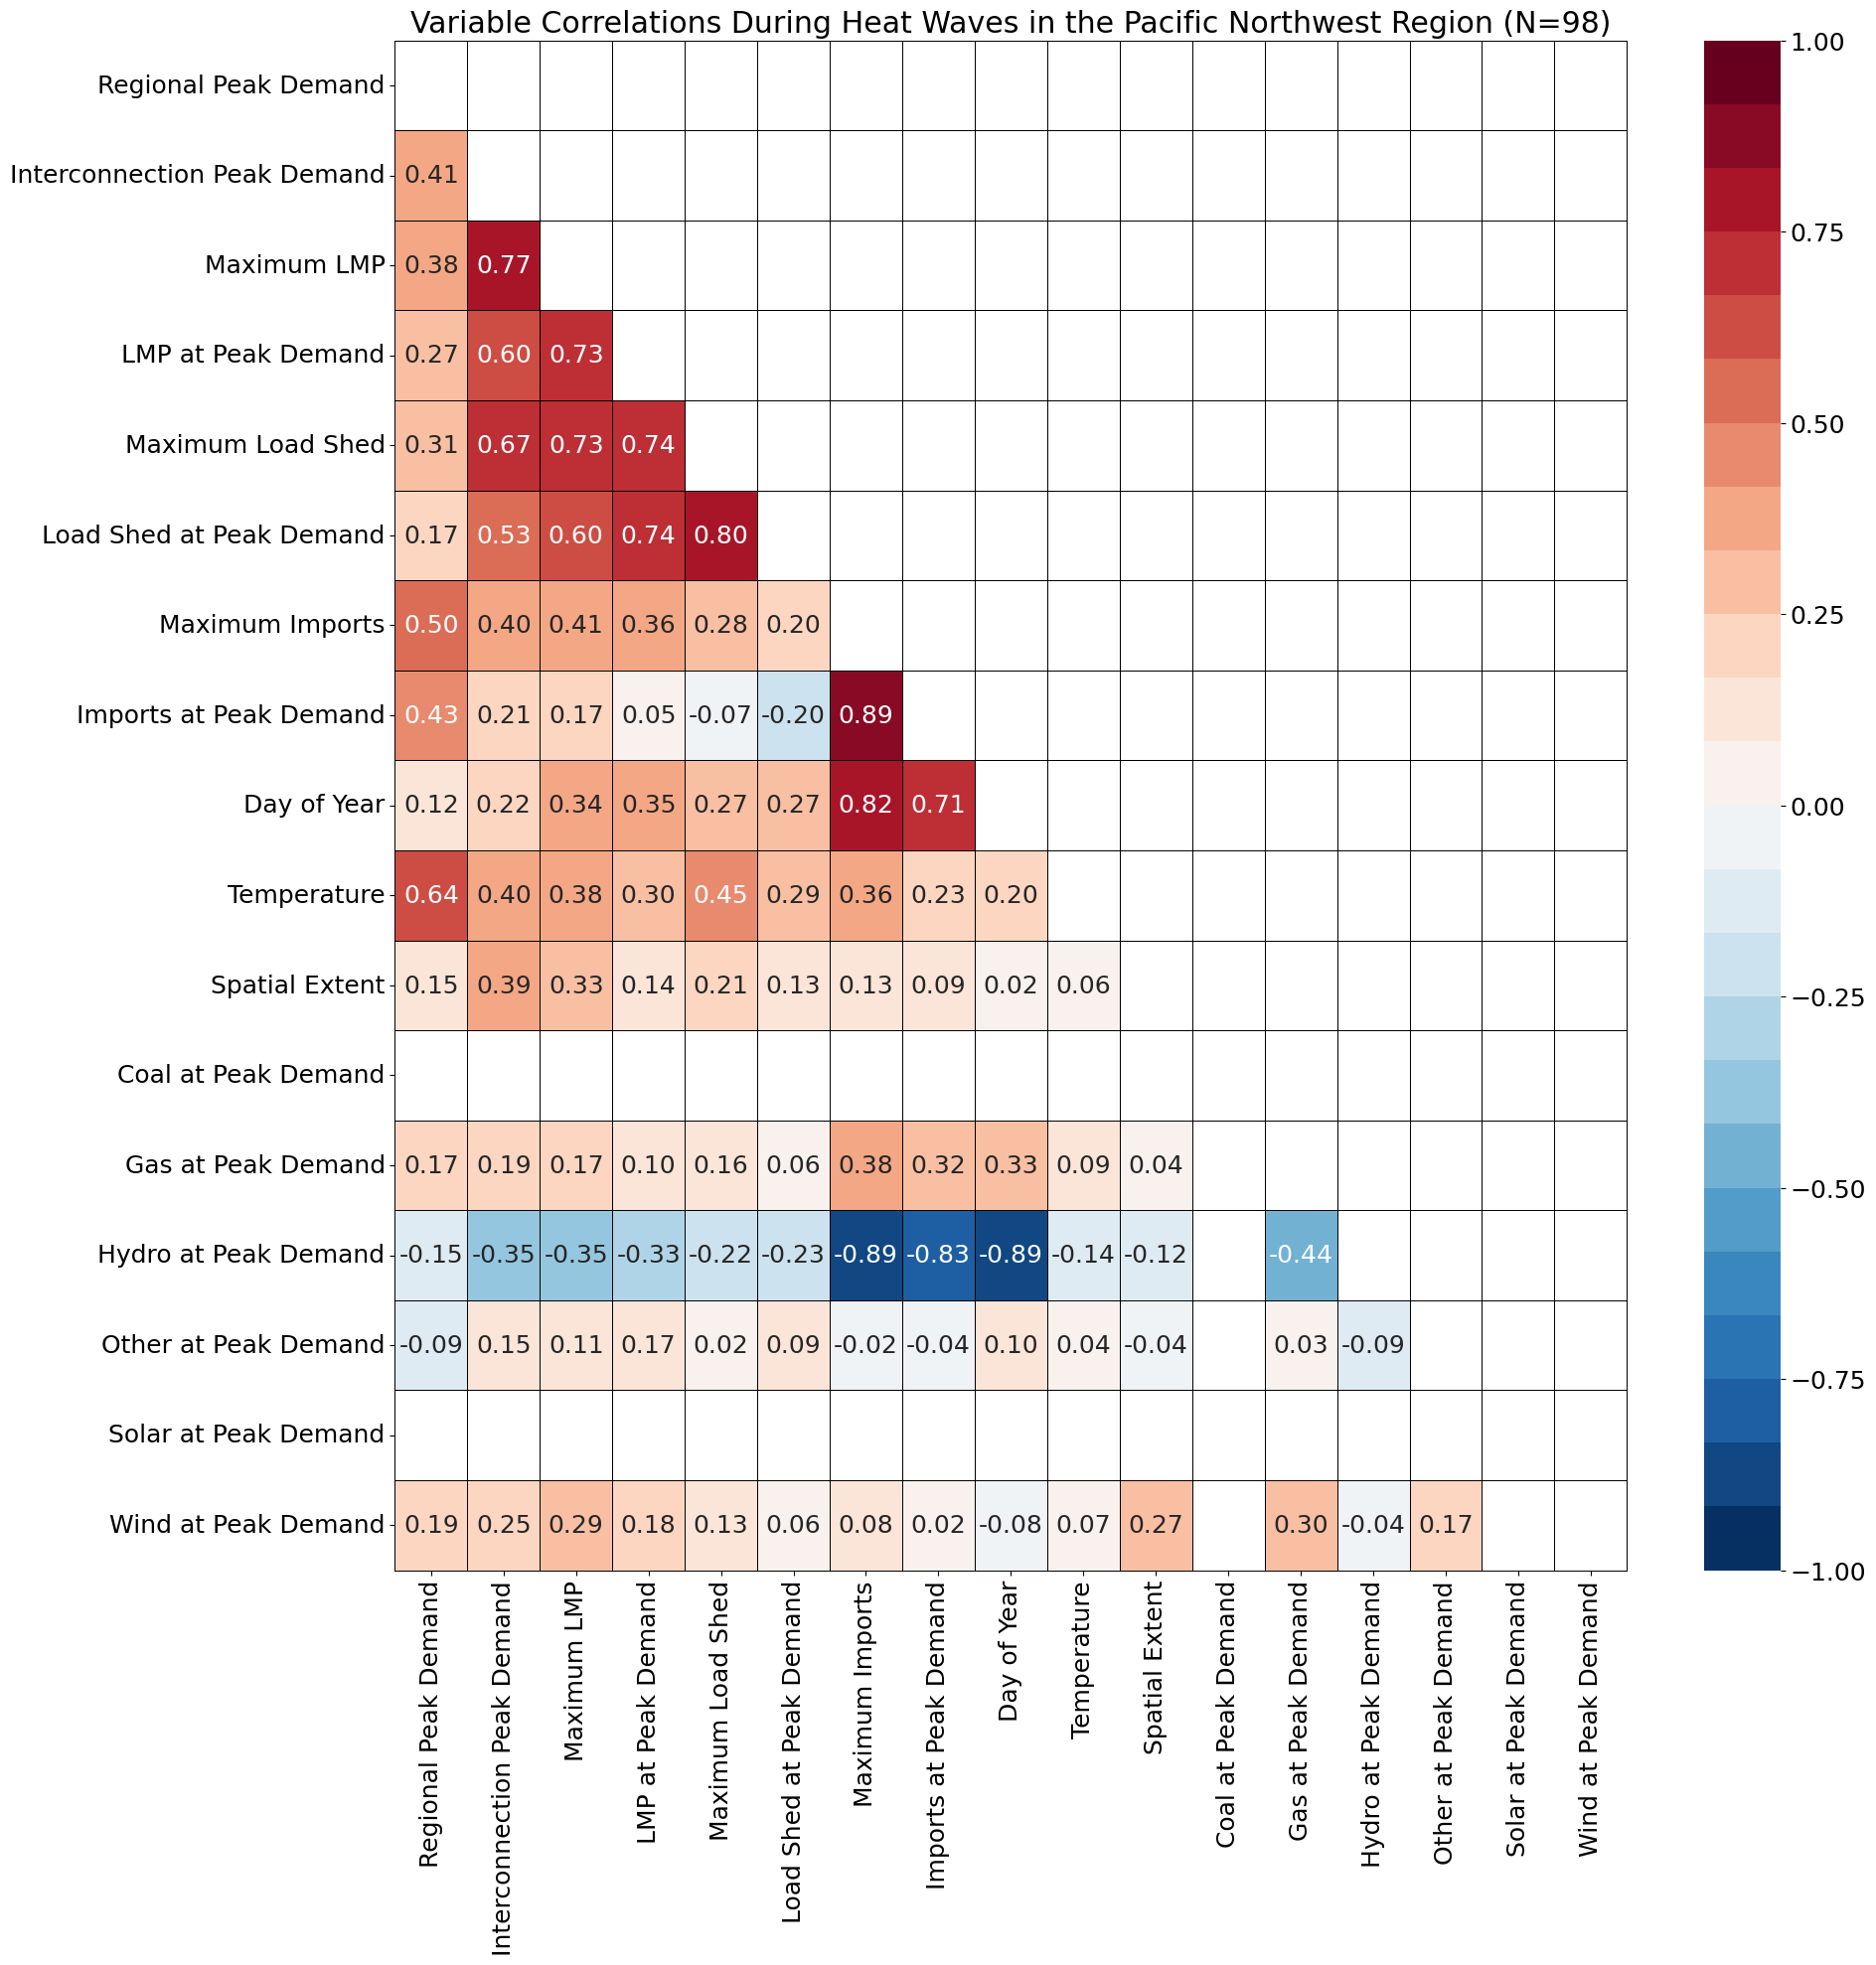

In [46]:
# Test the function:
plot_hw_cs_correlations(region = 'PNW',
                        hw_cs = 'HW',
                        events_data_input_dir = events_data_input_dir,
                        metadata_input_dir = metadata_input_dir,
                        image_output_dir = image_output_dir, 
                        image_resolution = 150,
                        save_images = False)


In [47]:
# Loop over the NERC TPL-008-1 regions and make the plot for each region:
for region in ['CA', 'GB', 'PNW', 'RM', 'SW']:

    # Loop over heat wave and cold snap event types:
    for event_type in ['HW', 'CS']:
    
        # Make the plot:
        plot_hw_cs_correlations(region = region,
                                hw_cs = event_type,
                                events_data_input_dir = events_data_input_dir,
                                metadata_input_dir = metadata_input_dir,
                                image_output_dir = image_output_dir, 
                                image_resolution = 150,
                                save_images = True)
